1. Import libraries

In [1]:
import os

filename = "1360-1800-5-4_smoothed.txt"
data_dir = os.path.join("..", "data", "Vera0925", "preprocessed")
data_file = os.path.join(data_dir, filename)

results_dir = os.path.join("..", "data", "Vera0925",  "results")
os.makedirs(results_dir, exist_ok=True)

DATA_FILE = data_file  # backward compatibility for downstream cells

print(f"Data file: {data_file}")
print(f"Results directory: {results_dir}")



Data file: ../data/Vera0925/preprocessed/1360-1800-5-4_smoothed.txt
Results directory: ../data/Vera0925/results


In [2]:
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
physics_root = os.path.join(project_root, "secondary_protein_deconvolution", "physics")

for path in (project_root, physics_root):
    if path not in sys.path:
        sys.path.append(path)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import lsq_linear
import pandas as pd
import seaborn as sns

%matplotlib inline

from physics.peak_detection import (
    detect_peaks, detect_peaks_sensitive, detect_broad_peaks,
    detect_plateau_peaks, detect_all_peaks_aggressive,
    detect_gradual_increase, detect_gradual_decrease, detect_all_slopes,
    detect_manual_peaks, combine_peaks
)
from physics.peak_classification import (
    classify_peak, classify_peaks, calculate_structure_ratios,
    print_peak_summary, get_peak_statistics, set_gamma_width
)
from physics.spectral_functions import (
    lorentzian, gaussian, voigt, build_basis_functions,
    normalize_spectrum, smooth_spectrum, baseline_correction
)

def lorentzian_area(amplitude, gamma):
    return np.pi * gamma * amplitude / 2


Load real experimental data

In [4]:
def load_txt_data(filename):
    """Load spectral data from a two-column TXT file."""
    try:
        import os
        if not os.path.exists(filename):
            print(f"Error: File {filename} not found!")
            return None, None

        print(f"Loading TXT file: {filename}")
        data = np.loadtxt(filename)
        print(f"TXT data loaded: {data.shape[0]} rows, {data.shape[1]} columns")

        if data.ndim != 2 or data.shape[1] < 2:
            print("Error: TXT file must contain at least two columns (wavenumber, intensity)")
            return None, None

        wavenumber = data[:, 0]
        spectra = data[:, 1:]

        order = np.argsort(wavenumber)
        wavenumber = wavenumber[order]
        spectra = spectra[order]

        # Normalize spectra to 0-1 range (consistent with Excel workflow)
        spectra = spectra - spectra.min(axis=0)
        max_vals = spectra.max(axis=0)
        max_vals[max_vals == 0] = 1.0
        spectra = spectra / max_vals

        wavenumber_array = wavenumber
        spectra_array = spectra.T  # shape (n_spectra, n_points)

        print(f"Valid data: {len(wavenumber_array)} rows")
        print(f"Wavenumber range: {wavenumber_array.min():.1f} - {wavenumber_array.max():.1f} cm⁻¹")
        print(f"Number of spectra: {len(spectra_array)}")
        print("Data conversion completed successfully")
        return wavenumber_array, spectra_array

    except Exception as e:
        print(f"Error loading TXT file: {e}")
        import traceback
        traceback.print_exc()
        return None, None

# Data file settings - TXT version (provided in the configuration cell)
DATA_FILE = data_file

# Load TXT data
print("Loading TXT data...")
wavenumber_axis, all_spectra = load_txt_data(DATA_FILE)

# Check if loading succeeded
if wavenumber_axis is None:
    print("Data loading failed. Please check the file path and format.")
    exit()

# Select which spectrum to analyze
SPECTRUM_INDEX = 0  # Only one spectrum in the TXT file

if 0 <= SPECTRUM_INDEX < len(all_spectra):
    spectrum1 = all_spectra[SPECTRUM_INDEX]
    print(f"Selected spectrum {SPECTRUM_INDEX + 1} for analysis")
else:
    print(f"Invalid spectrum index {SPECTRUM_INDEX}. Available: 0 to {len(all_spectra) - 1}")
    exit()

print(f"Data file: {DATA_FILE}")
print(f"Data range: {wavenumber_axis.min():.1f} - {wavenumber_axis.max():.1f} cm⁻¹")
print(f"Number of data points: {len(wavenumber_axis)}")
print(f"Number of spectra: {len(all_spectra)}")
if spectrum1 is not None:
    print(f"Spectrum1 range: {spectrum1.min():.6f} - {spectrum1.max():.6f}")


Loading TXT data...
Loading TXT file: ../data/Vera0925/preprocessed/1360-1800-5-4_smoothed.txt
TXT data loaded: 441 rows, 2 columns
Valid data: 441 rows
Wavenumber range: 1359.0 - 1799.0 cm⁻¹
Number of spectra: 1
Data conversion completed successfully
Selected spectrum 1 for analysis
Data file: ../data/Vera0925/preprocessed/1360-1800-5-4_smoothed.txt
Data range: 1359.0 - 1799.0 cm⁻¹
Number of data points: 441
Number of spectra: 1
Spectrum1 range: 0.000000 - 1.000000


2. Visualize original data

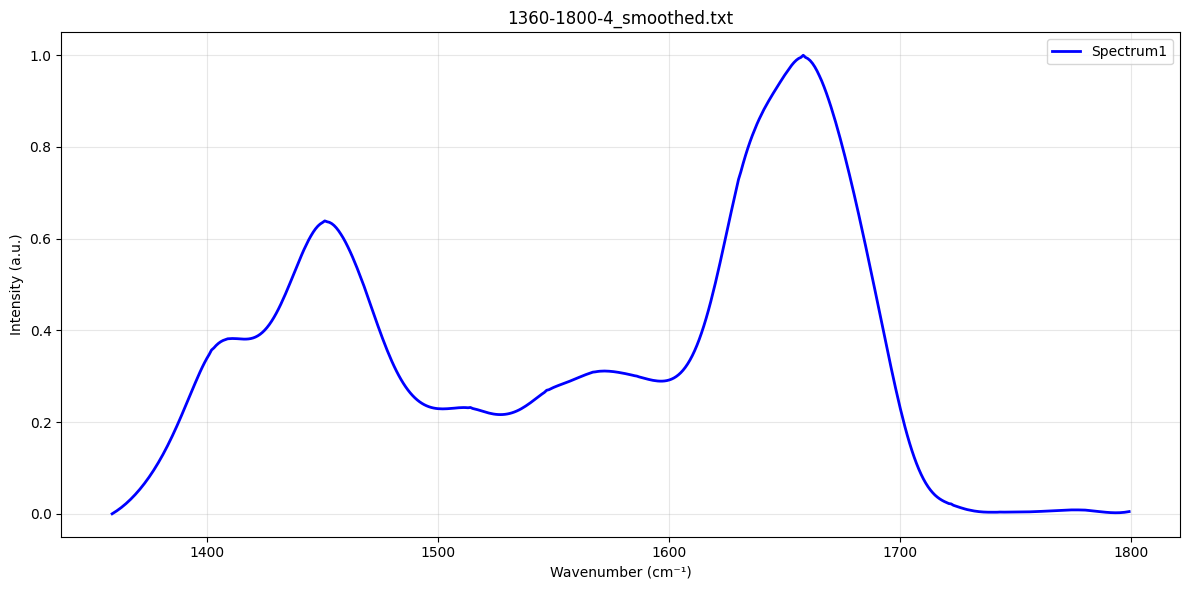

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(wavenumber_axis, spectrum1, 'b-', linewidth=2, label='Spectrum1')
plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Intensity (a.u.)')
plt.title('1360-1800-4_smoothed.txt')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Parameter Settings - Adjust key parameters here

In [6]:
GAMMA_WIDTH = 30  # Linewidth for all peak types (can be adjusted to 8.0, 10.0, 15.0, 20.0, etc.)

# Sharp peak detection (detect_peaks function)
SHARP_THRESHOLD = 0.03        # Intensity threshold (0.01-0.05)
SHARP_MIN_DISTANCE = 12         # Minimum distance between peaks (5-15)

# Broad peak detection (detect_broad_peaks function)
BROAD_WINDOW_SIZE = 15         # Window size (8-20)
BROAD_THRESHOLD_RATIO = 0.035  # Threshold ratio (0.02-0.05)

# Plateau peak detection (detect_plateau_peaks function)
PLATEAU_MIN_WIDTH = 12         # Minimum width (8-15)
PLATEAU_THRESHOLD_RATIO = 0.025 # Threshold ratio (0.02-0.05)

# Gradual increase detection (detect_gradual_increase function)
GRADUAL_WINDOW_SIZE = 25       # Window size for gradual detection
GRADUAL_MIN_INCREASE = 0.00005 # Minimum increase

# Peak combination (combine_peaks function)
COMBINE_DISTANCE = 10           # Combine distance (5-12)

# Physical constraint parameters
PHYSICAL_WINDOW_SIZE = 10  # Window size for checking around peaks (8-15)

3. Peak detection and analysis

Detected 30 peaks
Sharp peaks: 5
Broad peaks: 5
Plateau peaks: 0
Aggressive detection peaks: 20
Gradual increase peaks: 19
Gradual decrease peaks: 16
All slope peaks (reference): 33
Peak positions: [1411. 1451. 1511. 1572. 1657. 1746. 1775. 1391. 1401. 1441. 1626. 1636.
 1371. 1431. 1531. 1543. 1555. 1601. 1613. 1760. 1468. 1480. 1492. 1589.
 1674. 1686. 1698. 1710. 1722. 1734.]
Peak heights: [0.38232655 0.63723877 0.23178135 0.31135951 0.99621247 0.00370783
 0.00853335 0.23804661 0.34801419 0.56463966 0.63909566 0.82536696
 0.05353156 0.44689901 0.21882317 0.25371045 0.285298   0.29364233
 0.38030397 0.00505757 0.49572972 0.33275566 0.24435283 0.29584999
 0.81843433 0.56023005 0.27289394 0.07592462 0.02061791 0.00472923]


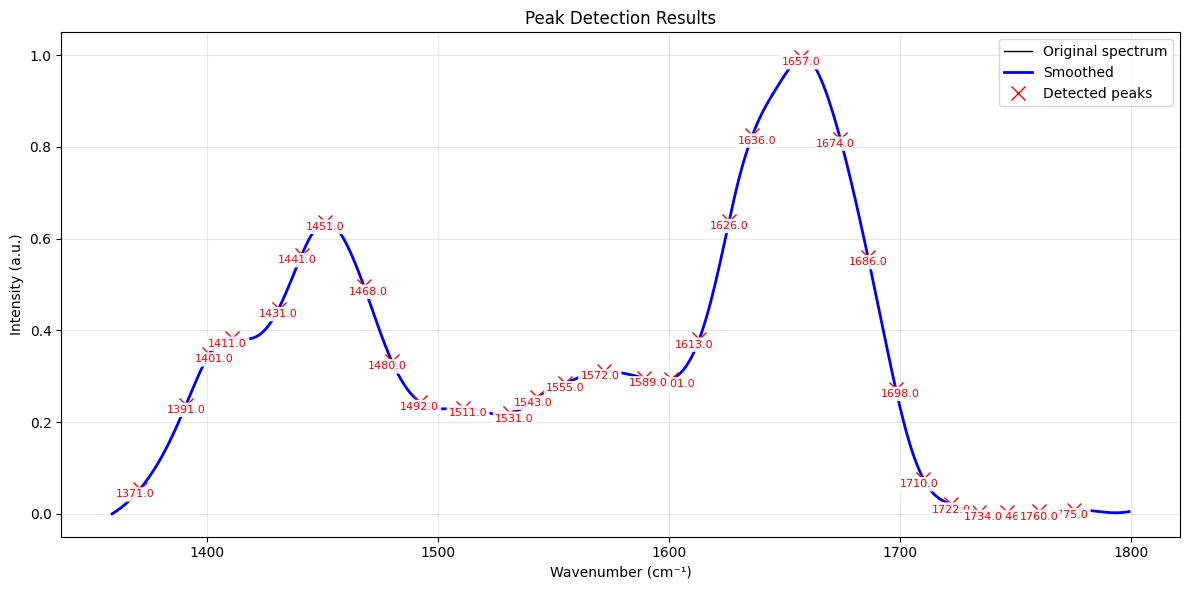

In [7]:
# Select spectrum to analyze
y = spectrum1

# Step 1: Peak detection - using aggressive multi-method combination
# Method 1: Detect sharp peaks
sharp_peaks, y_smooth = detect_peaks(y, wavenumber_axis, 
                                    threshold=SHARP_THRESHOLD, 
                                    min_distance=SHARP_MIN_DISTANCE)

# Method 2: Detect gradual/broad peaks
broad_peaks, _ = detect_broad_peaks(y, wavenumber_axis, 
                                   window_size=BROAD_WINDOW_SIZE, 
                                   threshold_ratio=BROAD_THRESHOLD_RATIO)

# Method 3: Detect plateau/gradual slopes
plateau_peaks, _ = detect_plateau_peaks(y, wavenumber_axis, 
                                       min_width=PLATEAU_MIN_WIDTH, 
                                       threshold_ratio=PLATEAU_THRESHOLD_RATIO)

# Method 4: Aggressive all-peak detection
aggressive_peaks, _ = detect_all_peaks_aggressive(y, wavenumber_axis)

# Method 5: Detect gradual slopes/progressive increase
gradual_peaks, _ = detect_gradual_increase(y, wavenumber_axis, 
                                          window_size=GRADUAL_WINDOW_SIZE, 
                                          min_increase=GRADUAL_MIN_INCREASE)

# Method 6: Detect gradual slopes/progressive decrease
decrease_peaks, _ = detect_gradual_decrease(y, wavenumber_axis, 
                                           window_size=GRADUAL_WINDOW_SIZE, 
                                           min_decrease=GRADUAL_MIN_INCREASE)  # Using same threshold for consistency

# Method 7: Detect all slopes (both increase and decrease) - alternative approach
all_slope_peaks, _ = detect_all_slopes(y, wavenumber_axis, 
                                       window_size=GRADUAL_WINDOW_SIZE, 
                                       min_change=GRADUAL_MIN_INCREASE)

# Ensure y_smooth is available for later use
if y_smooth is None:
    # If detect_peaks didn't return y_smooth, create a simple smoothed version
    y_smooth = savgol_filter(y, window_length=11, polyorder=3)

# Combine all detected peaks (excluding all_slope_peaks to avoid redundancy)
all_peaks = np.concatenate([sharp_peaks, broad_peaks, plateau_peaks, aggressive_peaks, 
                           gradual_peaks, decrease_peaks])

# Remove duplicate peaks (peaks that are too close)
unique_peaks = []
for peak in all_peaks:
    too_close = False
    for existing in unique_peaks:
        if abs(peak - existing) < COMBINE_DISTANCE:  # Minimum distance
            too_close = True
            break
    if not too_close:
        unique_peaks.append(peak)

peak_indices = np.array(unique_peaks, dtype=int)
detected_positions = wavenumber_axis[peak_indices]
detected_heights = y_smooth[peak_indices]

print(f"Detected {len(detected_positions)} peaks")
print(f"Sharp peaks: {len(sharp_peaks)}")
print(f"Broad peaks: {len(broad_peaks)}")
print(f"Plateau peaks: {len(plateau_peaks)}")
print(f"Aggressive detection peaks: {len(aggressive_peaks)}")
print(f"Gradual increase peaks: {len(gradual_peaks)}")
print(f"Gradual decrease peaks: {len(decrease_peaks)}")
print(f"All slope peaks (reference): {len(all_slope_peaks)}")
print(f"Peak positions: {detected_positions}")
print(f"Peak heights: {detected_heights}")

# Visualize peak detection results
plt.figure(figsize=(12, 6))
plt.plot(wavenumber_axis, y, 'k', lw=1, label='Original spectrum')
plt.plot(wavenumber_axis, y_smooth, 'b', lw=2, label='Smoothed')
plt.plot(detected_positions, detected_heights, 'rx', markersize=10, label='Detected peaks')

# Label peak positions below peaks with white background
for i, (x, h) in enumerate(zip(detected_positions, detected_heights)):
    # All labels below peaks
    y_offset = h - 0.0005
    va = 'top'
    
    # Add horizontal offset for better spacing
    x_offset = x + (i % 3 - 1) * 2  # Small horizontal offset
    
    plt.text(x_offset, y_offset, f"{x:.1f}", 
             ha='center', va=va, fontsize=8, color='red',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, edgecolor='none'))

plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Intensity (a.u.)')
plt.title('Peak Detection Results')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



4. Peak classification


PEAK POSITION REFINEMENT

Window size = 2:
  Original positions: [1411. 1451. 1511. 1572. 1657. 1746. 1775. 1391. 1401. 1441. 1626. 1636.
 1371. 1431. 1531. 1543. 1555. 1601. 1613. 1760. 1468. 1480. 1492. 1589.
 1674. 1686. 1698. 1710. 1722. 1734.]
  Refined positions:  [1411. 1452. 1512. 1572. 1658. 1748. 1775. 1393. 1403. 1443. 1628. 1638.
 1373. 1433. 1533. 1545. 1557. 1603. 1615. 1762. 1466. 1478. 1490. 1587.
 1672. 1684. 1696. 1708. 1720. 1732.]
  Position changes:   [ 0.  1.  1.  0.  1.  2.  0.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.
  2.  2. -2. -2. -2. -2. -2. -2. -2. -2. -2. -2.]

Window size = 3:
  Original positions: [1411. 1451. 1511. 1572. 1657. 1746. 1775. 1391. 1401. 1441. 1626. 1636.
 1371. 1431. 1531. 1543. 1555. 1601. 1613. 1760. 1468. 1480. 1492. 1589.
 1674. 1686. 1698. 1710. 1722. 1734.]
  Refined positions:  [1411. 1452. 1512. 1572. 1658. 1749. 1775. 1394. 1404. 1444. 1629. 1639.
 1374. 1434. 1534. 1546. 1558. 1604. 1616. 1763. 1465. 1477. 1489. 1586.
 1671. 

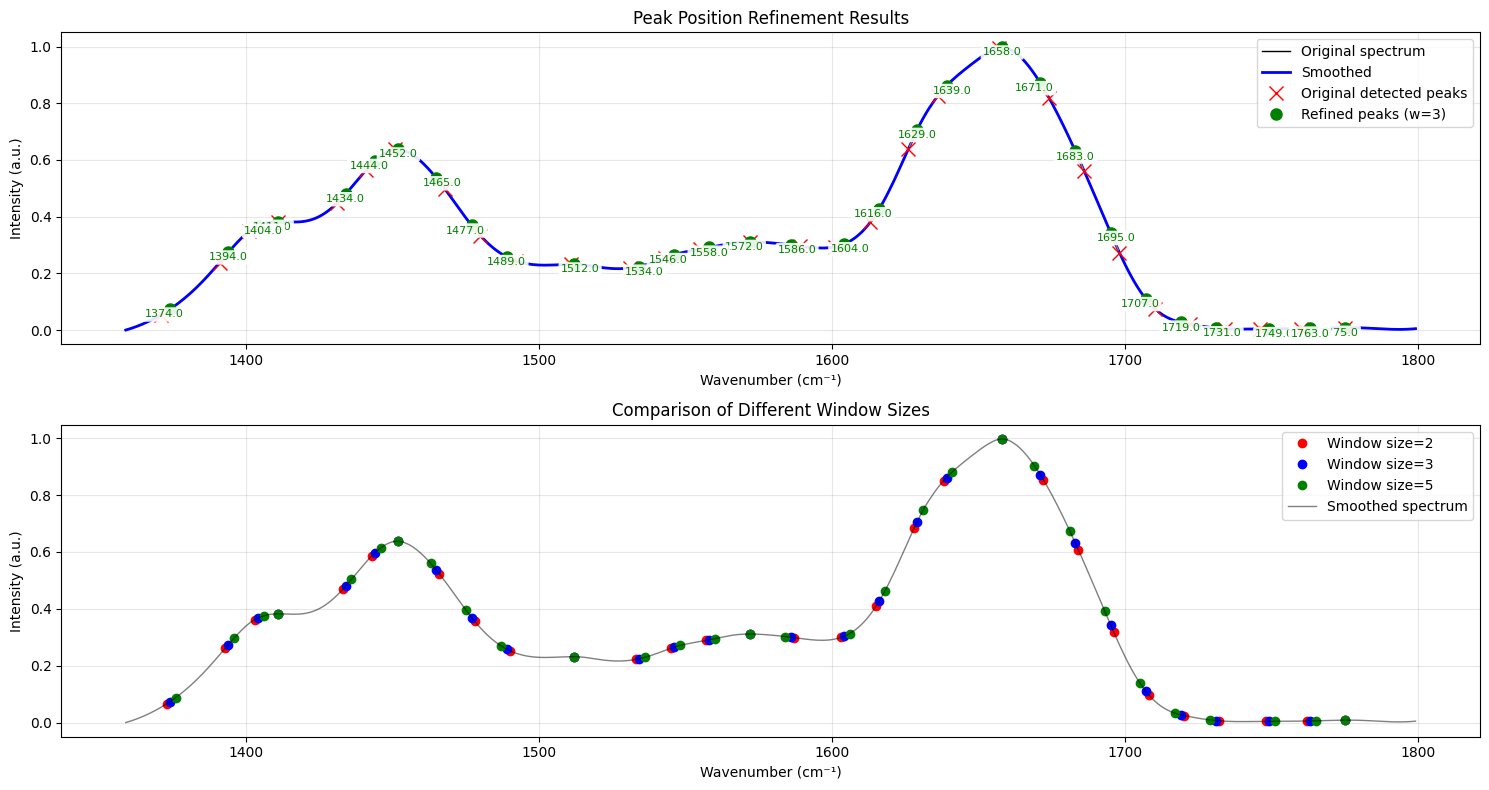


Final refined peak detection:
  Number of peaks: 30
  Peak positions: [1411. 1452. 1512. 1572. 1658. 1749. 1775. 1394. 1404. 1444. 1629. 1639.
 1374. 1434. 1534. 1546. 1558. 1604. 1616. 1763. 1465. 1477. 1489. 1586.
 1671. 1683. 1695. 1707. 1719. 1731.]
  Peak heights: [0.38232655 0.63737287 0.2318028  0.31135951 0.99708647 0.00376623
 0.00853335 0.27413634 0.36748464 0.59687934 0.70647483 0.86131963
 0.07297771 0.47955434 0.22403523 0.26502667 0.29123753 0.30301829
 0.42646831 0.00583032 0.53574138 0.3692129  0.25785286 0.29997636
 0.87140132 0.63003221 0.34291039 0.10974836 0.02689607 0.00696286]


In [8]:
def refine_peak_positions(wavenumber_axis, spectrum, peak_indices, window_size=3):
    """
    Refine peak positions by finding the true maximum within a local window
    """
    refined_indices = []
    refined_positions = []
    refined_heights = []
    
    for peak_idx in peak_indices:
        start_idx = max(0, peak_idx - window_size)
        end_idx = min(len(spectrum) - 1, peak_idx + window_size + 1)
        
        local_indices = np.arange(start_idx, end_idx)
        local_intensities = spectrum[local_indices]
        
        local_max_idx = np.argmax(local_intensities)
        refined_idx = local_indices[local_max_idx]
        
        refined_indices.append(refined_idx)
        refined_positions.append(wavenumber_axis[refined_idx])
        refined_heights.append(spectrum[refined_idx])
    
    return np.array(refined_indices), np.array(refined_positions), np.array(refined_heights)

print("\n" + "="*60)
print("PEAK POSITION REFINEMENT")
print("="*60)

window_sizes = [2, 3, 5]
refined_results = {}

for w in window_sizes:
    refined_indices, refined_positions, refined_heights = refine_peak_positions(
        wavenumber_axis, y_smooth, peak_indices, window_size=w
    )
    refined_results[w] = {
        'indices': refined_indices,
        'positions': refined_positions,
        'heights': refined_heights
    }
    
    print(f"\nWindow size = {w}:")
    print(f"  Original positions: {detected_positions}")
    print(f"  Refined positions:  {refined_positions}")
    print(f"  Position changes:   {refined_positions - detected_positions}")

best_window = 3
best_refined_indices = refined_results[best_window]['indices']
best_refined_positions = refined_results[best_window]['positions']
best_refined_heights = refined_results[best_window]['heights']

original_heights = detected_heights
height_improvements = best_refined_heights - original_heights
position_shifts = best_refined_positions - detected_positions

print(f"\nBest refinement (window_size={best_window}):")
print(f"  Height improvements: {height_improvements}")
print(f"  Average height improvement: {np.mean(height_improvements):.6f}")
print(f"  Average position shift: {np.mean(np.abs(position_shifts)):.3f} cm⁻¹")

plt.figure(figsize=(15, 8))
plt.subplot(2, 1, 1)
plt.plot(wavenumber_axis, y, 'k', lw=1, label='Original spectrum')
plt.plot(wavenumber_axis, y_smooth, 'b', lw=2, label='Smoothed')
plt.plot(detected_positions, detected_heights, 'rx', markersize=10, label='Original detected peaks')
plt.plot(best_refined_positions, best_refined_heights, 'go', markersize=8, label=f'Refined peaks (w={best_window})')

for i in range(len(detected_positions)):
    plt.annotate('', xy=(best_refined_positions[i], best_refined_heights[i]),
                xytext=(detected_positions[i], detected_heights[i]),
                arrowprops=dict(arrowstyle='->', color='orange', alpha=0.7, lw=1))

for i, (x, h) in enumerate(zip(best_refined_positions, best_refined_heights)):
    y_offset = h - 0.0005
    x_offset = x + (i % 3 - 1) * 2
    plt.text(x_offset, y_offset, f"{x:.1f}", 
             ha='center', va='top', fontsize=8, color='green',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, edgecolor='none'))

plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Intensity (a.u.)')
plt.title('Peak Position Refinement Results')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
colors = ['red', 'blue', 'green']
for i, w in enumerate(window_sizes):
    pos = refined_results[w]['positions']
    heights = refined_results[w]['heights']
    plt.plot(pos, heights, 'o', color=colors[i], markersize=6, 
             label=f'Window size={w}')

plt.plot(wavenumber_axis, y_smooth, 'k', lw=1, alpha=0.5, label='Smoothed spectrum')
plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Intensity (a.u.)')
plt.title('Comparison of Different Window Sizes')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

peak_indices = best_refined_indices
detected_positions = best_refined_positions
detected_heights = best_refined_heights

print(f"\nFinal refined peak detection:")
print(f"  Number of peaks: {len(detected_positions)}")
print(f"  Peak positions: {detected_positions}")
print(f"  Peak heights: {detected_heights}")


5. Peak classification

In [9]:
selected_types, selected_gammas = classify_peaks(detected_positions, gamma_width=GAMMA_WIDTH)
selected_centers = detected_positions.copy()

selected_centers = np.array(selected_centers)
selected_types = np.array(selected_types)
selected_gammas = np.array(selected_gammas)


6. Build basis functions

In [10]:
if len(selected_centers) > 0:
    B = build_basis_functions(wavenumber_axis, selected_centers, selected_gammas, 'lorentzian')
    print(f"Basis function matrix shape: {B.shape}")
    print(f"Number of basis functions: {B.shape[1]}")
else:
    print("Skip basis function construction, no valid peaks detected.")

Basis function matrix shape: (441, 30)
Number of basis functions: 30


7. NNLS optimization

In [11]:
if len(selected_centers) > 0:
    bounds = (0, np.inf)
    res = lsq_linear(B, y, bounds=bounds, lsq_solver='exact')
    amplitudes = res.x
    
    recon = B @ amplitudes
    recon = np.minimum(recon, y)
    
    for j in range(len(amplitudes)):
        peak_curve = B[:, j] * amplitudes[j]
        peak_center = selected_centers[j]
        peak_idx = np.abs(wavenumber_axis - peak_center).argmin()
        
        window_size = PHYSICAL_WINDOW_SIZE
        start_idx = max(0, peak_idx - window_size)
        end_idx = min(len(y), peak_idx + window_size)
        
        peak_window = peak_curve[start_idx:end_idx]
        original_window = y[start_idx:end_idx]
        
        if np.max(peak_window) > np.max(original_window):
            scale_factor = np.max(original_window) / np.max(peak_window)
            amplitudes[j] *= scale_factor
            print(f"Adjust amplitude of peak {j+1} ({peak_center:.1f} cm⁻¹), scale factor: {scale_factor:.3f}")
    
    recon = B @ amplitudes
    recon = np.minimum(recon, y)
    
    print(f"Optimization successful! Residual: {res.cost:.6f}")
    print(f"Amplitude coefficients: {amplitudes}")
    
    mse = np.mean((y - recon)**2)
    rmse = np.sqrt(mse)
    print(f"Reconstruction error - MSE: {mse:.8f}, RMSE: {rmse:.6f}")
else:
    print("Skip NNLS optimization, no valid peaks detected.")

Optimization successful! Residual: 0.183545
Amplitude coefficients: [1.03359642e-01 3.03943246e-01 1.01529530e-01 1.00157285e-01
 5.33093247e-01 4.07937138e-26 2.02920761e-25 1.91983751e-02
 1.77013572e-01 1.01713198e-01 1.71802162e-01 4.29985465e-01
 2.38857094e-20 1.58282499e-01 4.34352674e-02 6.50796558e-02
 8.85851478e-02 1.35388888e-02 4.99862454e-02 1.18912335e-25
 2.11512089e-01 4.72419629e-02 3.56273531e-02 9.74165670e-02
 3.51407292e-01 1.67443040e-01 1.47109814e-23 2.34091118e-25
 2.89597028e-26 1.74943572e-26]
Reconstruction error - MSE: 0.00007419, RMSE: 0.008613


8. Visualize decomposition results (wiz other)

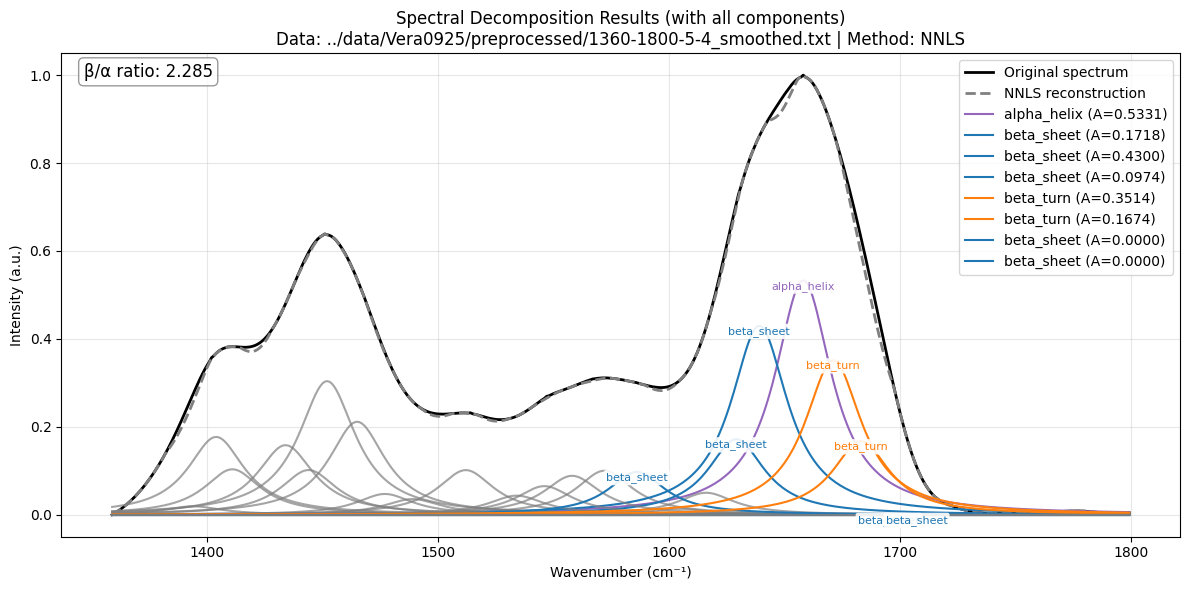

β/α ratio: 2.285
Total β structure area: 57.399467
α-helix area: 25.121427
Unknown type area: 76.350313


In [12]:
if len(selected_centers) > 0:
    plt.figure(figsize=(12, 6))
    plt.plot(wavenumber_axis, y, 'k', lw=2, label='Original spectrum')
    plt.plot(wavenumber_axis, recon, '--', color='gray', lw=2, label='NNLS reconstruction')
    
    colors = {'beta_sheet': 'tab:blue', 'alpha_helix': 'tab:purple', 'beta_turn': 'tab:orange', 'unknown': 'tab:gray'}
    
    for j, (c, fam, a) in enumerate(zip(selected_centers, selected_types, amplitudes)):
        peak_curve = B[:, j] * a
        if fam == "unknown":
            plt.plot(wavenumber_axis, peak_curve, color=colors[fam], lw=1.5, alpha=0.7)
        else:
            plt.plot(wavenumber_axis, peak_curve, color=colors[fam], lw=1.5, 
                    label=f'{fam} (A={a:.4f})')
            peak_idx = np.abs(wavenumber_axis - c).argmin()
            y_offset = peak_curve[peak_idx] - 0.0005
            plt.text(wavenumber_axis[peak_idx], y_offset, fam, 
                    color=colors[fam], fontsize=8, ha='center', va='top',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, edgecolor='none'))
    
    areas = lorentzian_area(amplitudes, selected_gammas)
    beta_area = sum(area for area, fam in zip(areas, selected_types) 
                   if fam in ['beta_sheet', 'beta_turn'])
    alpha_area = sum(area for area, fam in zip(areas, selected_types) 
                    if fam == 'alpha_helix')
    beta_alpha_ratio = beta_area / alpha_area if alpha_area > 0 else float('inf')
    
    plt.xlabel('Wavenumber (cm⁻¹)')
    plt.ylabel('Intensity (a.u.)')
    plt.title(f'Spectral Decomposition Results (with all components)\nData: {DATA_FILE} | Method: NNLS')
    
    if alpha_area > 0:
        plt.text(0.02, 0.98, f'β/α ratio: {beta_alpha_ratio:.3f}', 
                transform=plt.gca().transAxes, fontsize=12, 
                verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', 
                facecolor='white', alpha=0.8, edgecolor='gray'))
    else:
        plt.text(0.02, 0.98, 'β/α ratio: No α-helix detected', 
                transform=plt.gca().transAxes, fontsize=12, 
                verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', 
                facecolor='white', alpha=0.8, edgecolor='gray'))
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    areas = lorentzian_area(amplitudes, selected_gammas)
    beta_area = sum(area for area, fam in zip(areas, selected_types) 
                   if fam in ['beta_sheet', 'beta_turn'])
    alpha_area = sum(area for area, fam in zip(areas, selected_types) 
                    if fam == 'alpha_helix')
    unknown_area = sum(area for area, fam in zip(areas, selected_types) 
                     if fam == 'unknown')
    
    if alpha_area > 0:
        beta_alpha_ratio = beta_area / alpha_area
        print(f"β/α ratio: {beta_alpha_ratio:.3f}")
    else:
        print("No α-helix structure detected")
    
    print(f"Total β structure area: {beta_area:.6f}")
    print(f"α-helix area: {alpha_area:.6f}")
    print(f"Unknown type area: {unknown_area:.6f}")
else:
    print("No valid peaks detected for visualization")



9. Visualize decomposition results

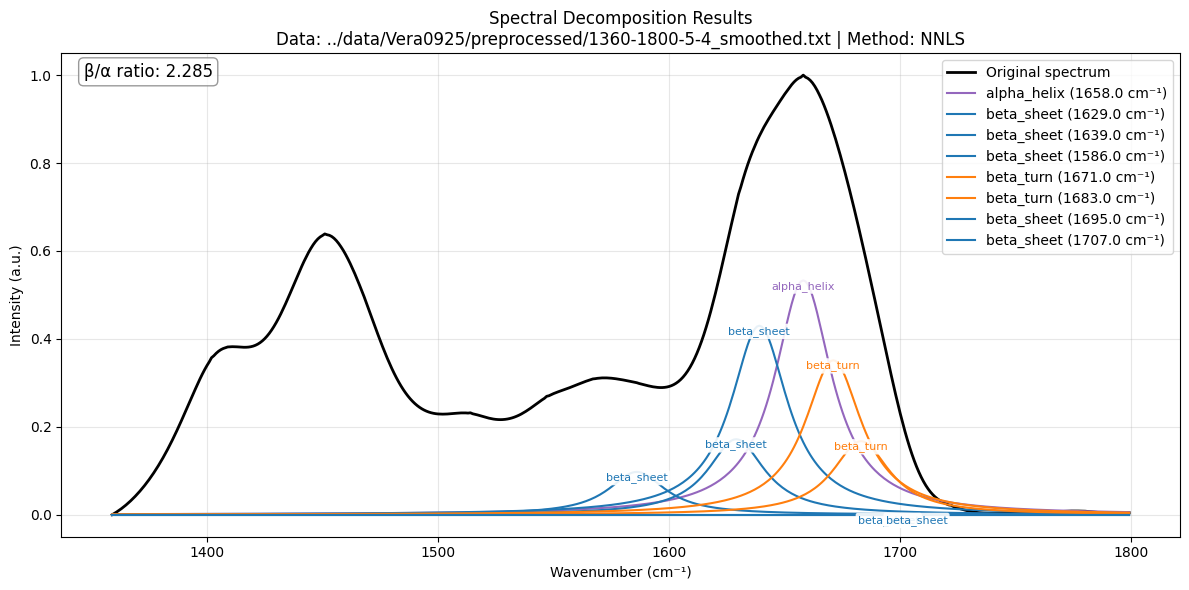

Known structure component contribution ratio: 51.9%
Number of known structure components: 8


In [13]:
if len(selected_centers) > 0:
    known_components = []
    known_names = []
    known_centers = []
    
    for j, (c, fam, a) in enumerate(zip(selected_centers, selected_types, amplitudes)):
        if fam != "unknown":
            peak_curve = B[:, j] * a
            known_components.append(peak_curve)
            known_names.append(f"{fam} ({c:.1f} cm⁻¹)")
            known_centers.append(c)
    
    if len(known_components) > 0:
        plt.figure(figsize=(12, 6))
        plt.plot(wavenumber_axis, y, 'k', lw=2, label='Original spectrum')
        
        colors = {'beta_sheet': 'tab:blue', 'alpha_helix': 'tab:purple', 'beta_turn': 'tab:orange'}
        
        for component, name, center in zip(known_components, known_names, known_centers):
            fam = name.split(' ')[0]
            plt.plot(wavenumber_axis, component, color=colors[fam], lw=1.5, 
                    label=name)
            peak_idx = np.abs(wavenumber_axis - center).argmin()
            y_offset = component[peak_idx] - 0.0005
            plt.text(wavenumber_axis[peak_idx], y_offset, fam, 
                    color=colors[fam], fontsize=8, ha='center', va='top',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, edgecolor='none'))
        
        areas = lorentzian_area(amplitudes, selected_gammas)
        beta_area = sum(area for area, fam in zip(areas, selected_types) 
                       if fam in ['beta_sheet', 'beta_turn'])
        alpha_area = sum(area for area, fam in zip(areas, selected_types) 
                        if fam == 'alpha_helix')
        beta_alpha_ratio = beta_area / alpha_area if alpha_area > 0 else float('inf')
        
        plt.xlabel('Wavenumber (cm⁻¹)')
        plt.ylabel('Intensity (a.u.)')
        plt.title(f'Spectral Decomposition Results\nData: {DATA_FILE} | Method: NNLS')
        
        if alpha_area > 0:
            plt.text(0.02, 0.98, f'β/α ratio: {beta_alpha_ratio:.3f}', 
                    transform=plt.gca().transAxes, fontsize=12, 
                    verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', 
                    facecolor='white', alpha=0.8, edgecolor='gray'))
        else:
            plt.text(0.02, 0.98, 'β/α ratio: No α-helix detected', 
                    transform=plt.gca().transAxes, fontsize=12, 
                    verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', 
                    facecolor='white', alpha=0.8, edgecolor='gray'))
        
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        known_recon = np.sum(known_components, axis=0)
        known_recon = np.minimum(known_recon, y)
        
        areas = lorentzian_area(amplitudes, selected_gammas)
        total_known_area = sum(area for area, fam in zip(areas, selected_types) if fam != "unknown")
        total_area = sum(areas)
        known_ratio = total_known_area / total_area if total_area > 0 else 0
        
        print(f"Known structure component contribution ratio: {known_ratio:.1%}")
        print(f"Number of known structure components: {len(known_components)}")
    else:
        print("No peaks of known structure types detected")
else:
    print("Skip known component visualization")

In [14]:
SAVE_FIGURES = True

if SAVE_FIGURES:
    base_name = os.path.splitext(filename)[0]

    if len(selected_centers) > 0:
        # Figure with all components
        fig_all, ax_all = plt.subplots(figsize=(12, 6))
        ax_all.plot(wavenumber_axis, y, 'k', lw=2, label='Original spectrum')
        ax_all.plot(wavenumber_axis, recon, '--', color='gray', lw=2, label='NNLS reconstruction')

        color_map = {
            'beta_sheet': 'tab:blue',
            'alpha_helix': 'tab:purple',
            'beta_turn': 'tab:orange',
            'unknown': 'tab:gray'
        }

        for j, (c, fam, a) in enumerate(zip(selected_centers, selected_types, amplitudes)):
            peak_curve = B[:, j] * a
            color = color_map.get(fam, 'tab:gray')
            if fam == "unknown":
                ax_all.plot(wavenumber_axis, peak_curve, color=color, lw=1.5, alpha=0.7)
            else:
                ax_all.plot(wavenumber_axis, peak_curve, color=color, lw=1.5,
                            label=f'{fam} (A={a:.4f})')
                peak_idx = np.abs(wavenumber_axis - c).argmin()
                y_offset = peak_curve[peak_idx] - 0.0005
                ax_all.text(wavenumber_axis[peak_idx], y_offset, fam,
                            color=color, fontsize=8, ha='center', va='top',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, edgecolor='none'))

        areas_all = lorentzian_area(amplitudes, selected_gammas)
        beta_area = sum(area for area, fam in zip(areas_all, selected_types)
                        if fam in ['beta_sheet', 'beta_turn'])
        alpha_area = sum(area for area, fam in zip(areas_all, selected_types)
                         if fam == 'alpha_helix')
        beta_alpha_ratio = beta_area / alpha_area if alpha_area > 0 else float('inf')

        ax_all.set_xlabel('Wavenumber (cm⁻¹)')
        ax_all.set_ylabel('Intensity (a.u.)')
        ax_all.set_title(f'Spectral Decomposition Results\nData: {DATA_FILE} | Method: NNLS')

        if alpha_area > 0:
            ax_all.text(0.02, 0.98, f'β/α ratio: {beta_alpha_ratio:.3f}',
                        transform=ax_all.transAxes, fontsize=12,
                        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3',
                        facecolor='white', alpha=0.8, edgecolor='gray'))
        else:
            ax_all.text(0.02, 0.98, 'β/α ratio: No α-helix detected',
                        transform=ax_all.transAxes, fontsize=12,
                        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3',
                        facecolor='white', alpha=0.8, edgecolor='gray'))

        ax_all.legend()
        ax_all.grid(True, alpha=0.3)
        fig_all.tight_layout()
        out_path_all = os.path.join(results_dir, f"{base_name} with all components.png")
        fig_all.savefig(out_path_all, dpi=300, bbox_inches='tight')
        plt.close(fig_all)

        # Figure with known components only
        known_components = []
        known_names = []
        known_centers = []
        for j, (c, fam, a) in enumerate(zip(selected_centers, selected_types, amplitudes)):
            if fam != "unknown":
                peak_curve = B[:, j] * a
                known_components.append(peak_curve)
                known_names.append(f"{fam} ({c:.1f} cm⁻¹)")
                known_centers.append(c)

        if len(known_components) > 0:
            fig_known, ax_known = plt.subplots(figsize=(12, 6))
            ax_known.plot(wavenumber_axis, y, 'k', lw=2, label='Original spectrum')
            colors_known = {'beta_sheet': 'tab:blue', 'alpha_helix': 'tab:purple', 'beta_turn': 'tab:orange'}

            for component, name, center in zip(known_components, known_names, known_centers):
                fam = name.split(' ')[0]
                color = colors_known.get(fam, 'tab:gray')
                ax_known.plot(wavenumber_axis, component, color=color, lw=1.5, label=name)
                peak_idx = np.abs(wavenumber_axis - center).argmin()
                y_offset = component[peak_idx] - 0.0005
                ax_known.text(wavenumber_axis[peak_idx], y_offset, fam,
                              color=color, fontsize=8, ha='center', va='top',
                              bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, edgecolor='none'))

            areas_known = lorentzian_area(amplitudes, selected_gammas)
            beta_area_known = sum(area for area, fam in zip(areas_known, selected_types)
                                  if fam in ['beta_sheet', 'beta_turn'])
            alpha_area_known = sum(area for area, fam in zip(areas_known, selected_types)
                                   if fam == 'alpha_helix')
            beta_alpha_ratio_known = beta_area_known / alpha_area_known if alpha_area_known > 0 else float('inf')

            ax_known.set_xlabel('Wavenumber (cm⁻¹)')
            ax_known.set_ylabel('Intensity (a.u.)')
            ax_known.set_title(f'Spectral Decomposition Results\nData: {DATA_FILE} | Method: NNLS')

            if alpha_area_known > 0:
                ax_known.text(0.02, 0.98, f'β/α ratio: {beta_alpha_ratio_known:.3f}',
                               transform=ax_known.transAxes, fontsize=12,
                               verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3',
                               facecolor='white', alpha=0.8, edgecolor='gray'))
            else:
                ax_known.text(0.02, 0.98, 'β/α ratio: No α-helix detected',
                               transform=ax_known.transAxes, fontsize=12,
                               verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3',
                               facecolor='white', alpha=0.8, edgecolor='gray'))

            ax_known.legend()
            ax_known.grid(True, alpha=0.3)
            fig_known.tight_layout()
            out_path_known = os.path.join(results_dir, f"{base_name}.png")
            fig_known.savefig(out_path_known, dpi=300, bbox_inches='tight')
            plt.close(fig_known)
        else:
            print("No known components to export.")
    else:
        print("No peaks available for figure export.")
else:
    print("SAVE_FIGURES is False; skipping figure export.")



10. Analysis results summary

In [15]:
print("=" * 60)
print("NNLS Analysis Results Summary")
print("=" * 60)

if len(selected_centers) > 0:
    mse = np.mean((y - recon)**2)
    print(f"Reconstruction error - MSE: {mse:.8f}")
    
    areas = lorentzian_area(amplitudes, selected_gammas)
    
    beta_area = sum(area for area, fam in zip(areas, selected_types) 
                   if fam in ['beta_sheet', 'beta_turn'])
    alpha_area = sum(area for area, fam in zip(areas, selected_types) 
                    if fam == 'alpha_helix')
    
    if alpha_area > 0:
        beta_alpha_ratio = beta_area / alpha_area
        print(f"β/α ratio: {beta_alpha_ratio:.3f}")
    else:
        print("No α-helix structure detected")
    
    print(f"Total β structure area: {beta_area:.6f}")
    print(f"α-helix area: {alpha_area:.6f}")
    
    print(f"\nDetected peaks:")
    for i, (pos, fam, amp) in enumerate(zip(selected_centers, selected_types, amplitudes)):
        if fam == "unknown":
            print(f"  Peak {i+1}: {pos:.1f} cm⁻¹ (Unknown type) - Amplitude: {amp:.6f}")
        else:
            print(f"  Peak {i+1}: {pos:.1f} cm⁻¹ ({fam}) - Amplitude: {amp:.6f}")
else:
    print("No valid peaks detected")



NNLS Analysis Results Summary
Reconstruction error - MSE: 0.00007419
β/α ratio: 2.285
Total β structure area: 57.399467
α-helix area: 25.121427

Detected peaks:
  Peak 1: 1411.0 cm⁻¹ (Unknown type) - Amplitude: 0.103360
  Peak 2: 1452.0 cm⁻¹ (Unknown type) - Amplitude: 0.303943
  Peak 3: 1512.0 cm⁻¹ (Unknown type) - Amplitude: 0.101530
  Peak 4: 1572.0 cm⁻¹ (Unknown type) - Amplitude: 0.100157
  Peak 5: 1658.0 cm⁻¹ (alpha_helix) - Amplitude: 0.533093
  Peak 6: 1749.0 cm⁻¹ (Unknown type) - Amplitude: 0.000000
  Peak 7: 1775.0 cm⁻¹ (Unknown type) - Amplitude: 0.000000
  Peak 8: 1394.0 cm⁻¹ (Unknown type) - Amplitude: 0.019198
  Peak 9: 1404.0 cm⁻¹ (Unknown type) - Amplitude: 0.177014
  Peak 10: 1444.0 cm⁻¹ (Unknown type) - Amplitude: 0.101713
  Peak 11: 1629.0 cm⁻¹ (beta_sheet) - Amplitude: 0.171802
  Peak 12: 1639.0 cm⁻¹ (beta_sheet) - Amplitude: 0.429985
  Peak 13: 1374.0 cm⁻¹ (Unknown type) - Amplitude: 0.000000
  Peak 14: 1434.0 cm⁻¹ (Unknown type) - Amplitude: 0.158282
  Peak 15: 15